In [ ]:
from pathlib import Path
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt

root = Path.cwd()
if root.name == 'notebooks':
    root = root.parent
sys.path.append(str(root))
import matplotlib.pyplot as plt


from GS_nodes import GaussianSplats, RenderSplat, splat_cloud_rotation, _read_ply_vertices


In [2]:
def load_splats_from_ply(path: str) -> GaussianSplats:
    data = _read_ply_vertices(path)
    required = [
        'x', 'y', 'z',
        'f_dc_0', 'f_dc_1', 'f_dc_2',
        'opacity',
        'scale_0', 'scale_1', 'scale_2',
        'rot_0', 'rot_1', 'rot_2', 'rot_3',
    ]
    missing = [name for name in required if name not in data]
    if missing:
        raise ValueError(f'Missing properties in PLY: {missing}')
    xyz = np.stack([data['x'], data['y'], data['z']], axis=1).astype(np.float32)
    scale = np.stack([data['scale_0'], data['scale_1'], data['scale_2']], axis=1).astype(np.float32)
    rotation = np.stack([data['rot_0'], data['rot_1'], data['rot_2'], data['rot_3']], axis=1).astype(np.float32)
    opacity = data['opacity'].astype(np.float32).reshape(-1, 1)
    f_dc = np.stack([data['f_dc_0'], data['f_dc_1'], data['f_dc_2']], axis=1).astype(np.float32)
    f_rest_keys = sorted([k for k in data.keys() if k.startswith('f_rest_')], key=lambda k: int(k.split('_')[-1]))
    if f_rest_keys:
        indices = [int(k.split('_')[-1]) for k in f_rest_keys]
        if indices != list(range(len(indices))):
            raise ValueError('f_rest indices must be contiguous starting at 0')
        f_rest = np.stack([data[k] for k in f_rest_keys], axis=1).astype(np.float32)
    else:
        f_rest = np.zeros((xyz.shape[0], 0), dtype=np.float32)
    return GaussianSplats(
        xyz=torch.from_numpy(xyz),
        scale=torch.from_numpy(scale),
        rotation=torch.from_numpy(rotation),
        opacity=torch.from_numpy(opacity),
        f_dc=torch.from_numpy(f_dc),
        f_rest=torch.from_numpy(f_rest),
    )

ply_path = r'C:\Projects\camera-comfyUI\screenshot1.ply'
splats = load_splats_from_ply(ply_path)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
splats = splats.to(device)
print('splats:', len(splats), 'sh_order:', splats.sh_order)


splats: 1179648 sh_order: 0


In [3]:
first = splats.get_splat(0)
batch = splats[:10]
print('first xyz shape:', first.xyz.shape)
print('batch xyz shape:', batch.xyz.shape)
coeffs = splats.sh_coeffs()
print('sh coeffs shape:', coeffs.shape)


first xyz shape: torch.Size([1, 3])
batch xyz shape: torch.Size([10, 3])
sh coeffs shape: torch.Size([1179648, 3, 1])


In [ ]:
angle = torch.tensor(45.0 * torch.pi / 180.0, device=device)
rot = torch.tensor(
    [
        [torch.cos(angle), 0.0, torch.sin(angle)],
        [0.0, 1.0, 0.0],
        [-torch.sin(angle), 0.0, torch.cos(angle)],
    ],
    device=device,
    dtype=torch.float32,
)
M = torch.eye(4, device=device)
M[:3, :3] = rot
rotated = splat_cloud_rotation(splats, M)
expected = splats.xyz[0] @ rot.T
print('rotation check:', torch.allclose(rotated.xyz[0], expected, atol=1e-4))


rotation check: True


(array([2.00000e+00, 5.00000e+00, 9.00000e+00, 1.70000e+01, 3.70000e+01,
        1.14000e+02, 3.10000e+02, 6.65000e+02, 1.29400e+03, 2.69800e+03,
        6.05500e+03, 1.18850e+04, 2.25600e+04, 4.00610e+04, 6.72920e+04,
        1.02351e+05, 1.39929e+05, 1.71870e+05, 1.98916e+05, 2.24122e+05,
        2.51042e+05, 2.65383e+05, 2.60755e+05, 2.33589e+05, 1.92389e+05,
        1.53507e+05, 1.31031e+05, 1.19792e+05, 1.09082e+05, 9.60300e+04,
        8.77160e+04, 8.33950e+04, 7.75550e+04, 6.74730e+04, 6.37030e+04,
        7.14220e+04, 5.70690e+04, 4.32740e+04, 3.77760e+04, 4.02890e+04,
        3.39090e+04, 1.82060e+04, 1.59050e+04, 1.43550e+04, 9.91500e+03,
        4.23000e+03, 2.07900e+03, 3.27100e+03, 3.91700e+03, 6.93000e+02]),
 array([-9.8898716 , -9.75400066, -9.61812973, -9.4822588 , -9.34638786,
        -9.21051598, -9.07464504, -8.93877411, -8.80290318, -8.66703224,
        -8.53116131, -8.39529037, -8.25941944, -8.12354851, -7.9876771 ,
        -7.85180616, -7.71593523, -7.58006382, -7

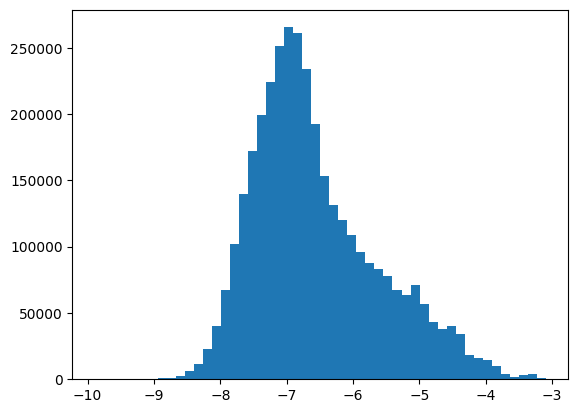

In [ ]:

#splats.scale.flatten().cpu().numpy()
plt.hist(splats.scale.flatten().cpu().numpy(), bins=50)

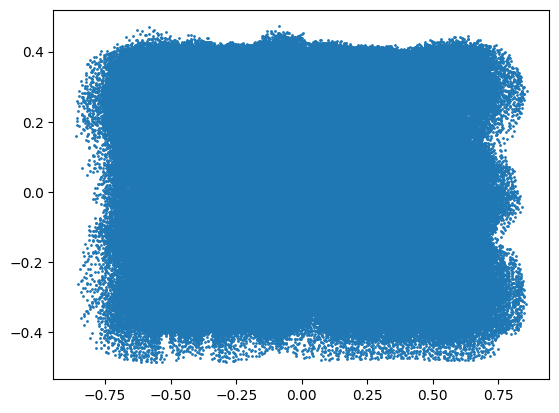

In [46]:
# plot xyz o
x,y,z=splats.xyz[:,0],splats.xyz[:,1],splats.xyz[:,2]
# pinhole camera
focal_length = 1.0
px = x / z * focal_length
py = y / z * focal_length
plt.scatter(px.cpu().numpy(), py.cpu().numpy(), s=1)

In [ ]:
# plot image of splats.rotation[:,0] depending on x and y
# show theta and phi scatter plot colored by splats.rotation[:,0]
plt.scatter(px.cpu().numpy(), py.cpu().numpy(), c=splats.rotation[:,2].cpu().numpy(), s=1)
plt.xlabel('x')
plt.ylabel('y')

Text(0, 0.5, 'theta')

In [21]:
splats.xyz.shape

torch.Size([1179648, 3])

(array([6.0000e+00, 2.3000e+01, 5.4000e+01, 9.8000e+01, 1.8700e+02,
        3.1400e+02, 5.9600e+02, 1.0140e+03, 1.8900e+03, 2.8500e+03,
        4.1970e+03, 6.2830e+03, 8.9580e+03, 1.2365e+04, 1.4772e+04,
        1.7271e+04, 2.0356e+04, 2.1797e+04, 2.3964e+04, 3.1041e+04,
        4.7172e+04, 6.7602e+04, 7.6863e+04, 7.3804e+04, 7.0490e+04,
        7.0885e+04, 7.3202e+04, 7.6177e+04, 7.8799e+04, 7.7383e+04,
        7.1340e+04, 6.0224e+04, 4.7399e+04, 3.4557e+04, 2.3587e+04,
        1.5506e+04, 1.1299e+04, 9.4020e+03, 8.4900e+03, 7.3060e+03,
        5.3550e+03, 2.7900e+03, 1.1320e+03, 4.6300e+02, 2.1600e+02,
        9.9000e+01, 3.2000e+01, 1.5000e+01, 2.0000e+01, 3.0000e+00]),
 array([-9.84057236, -9.34688568, -8.85319901, -8.35951138, -7.8658247 ,
        -7.37213802, -6.87845087, -6.38476419, -5.89107704, -5.39739037,
        -4.90370321, -4.41001654, -3.91632938, -3.42264271, -2.92895579,
        -2.43526888, -1.94158185, -1.44789493, -0.95420808, -0.46052116,
         0.03316574,  0.52

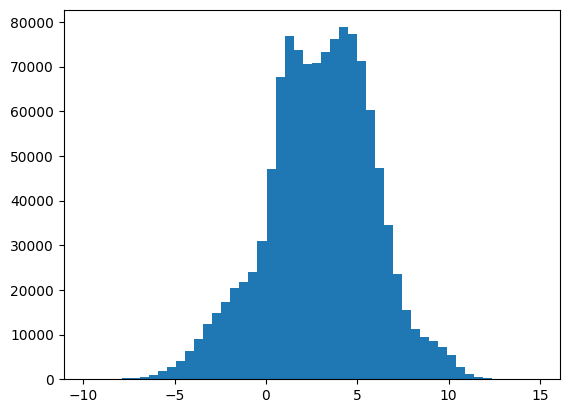

In [17]:
splats.rotation
plt.hist(splats.opacity.flatten().cpu().numpy(), bins=50)

In [9]:
splats.f_dc

tensor([[ 0.8371,  0.8370,  0.9024],
        [ 0.5582,  0.5965,  0.5719],
        [ 0.5752,  0.6227,  0.5913],
        ...,
        [-1.1020, -1.0950, -1.1001],
        [-1.0436, -1.0330, -1.0441],
        [-1.2455, -1.2441, -1.2464]], device='cuda:0')

(-0.5, 1023.5, 1023.5, -0.5)

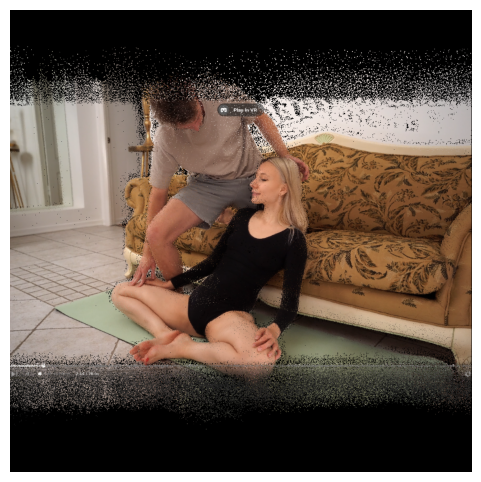

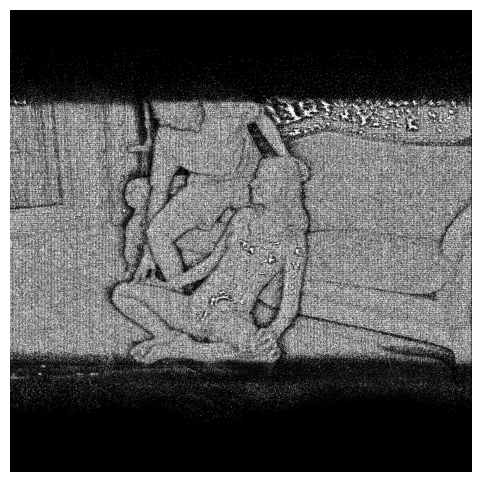

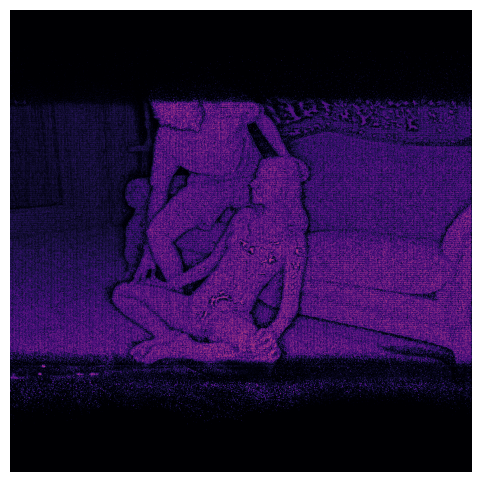

In [10]:
render = RenderSplat()
camera = torch.eye(4, device=device)
img, mask, disparity = render.render_splats(
    splats,
    camera,
    'PINHOLE',
    60.0,
    1024,
    1024,
    max_splats=2000000,
    opacity_is_logit=True,
    add_sh_bias=True,
)
img_np = img[0].detach().cpu().numpy()
mask_np = mask.detach().cpu().numpy()
disp_np = disparity[0, :, :, 0].detach().cpu().numpy()
plt.figure(figsize=(6, 6))
plt.imshow(img_np)
plt.axis('off')
plt.figure(figsize=(6, 6))
plt.imshow(mask_np, cmap='gray')
plt.axis('off')
plt.figure(figsize=(6, 6))
plt.imshow(disp_np, cmap='magma')
plt.axis('off')
